# CCO06: Change cell type number of clusters and conduct scVelo analysis

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import glob
import scipy

import scrublet as scr
from solo import hashsolo

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06

In [3]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO05"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO06"

## 1. Relabel cell type according to Jun's label

In [10]:
%%bash

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_labelled

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/dotplots

In [11]:
%%bash
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__ALL-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/ALL.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BHO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VHO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BVO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3B-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VCO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3O-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/CA.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__HO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/HO.h5ad

### 1.1 re-inspect data

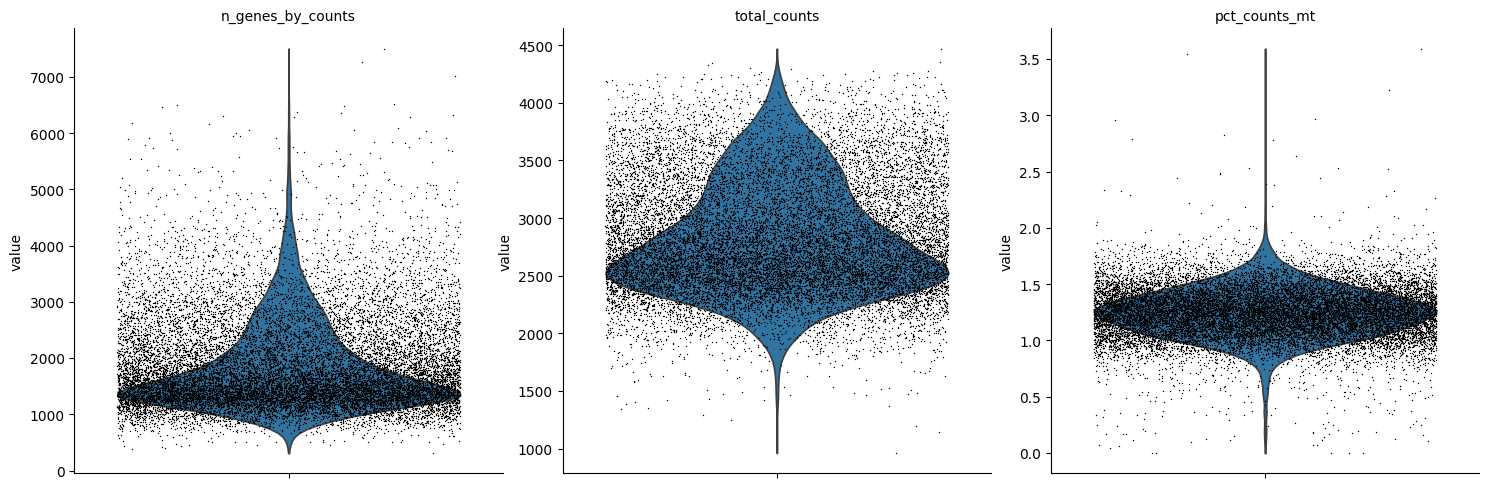

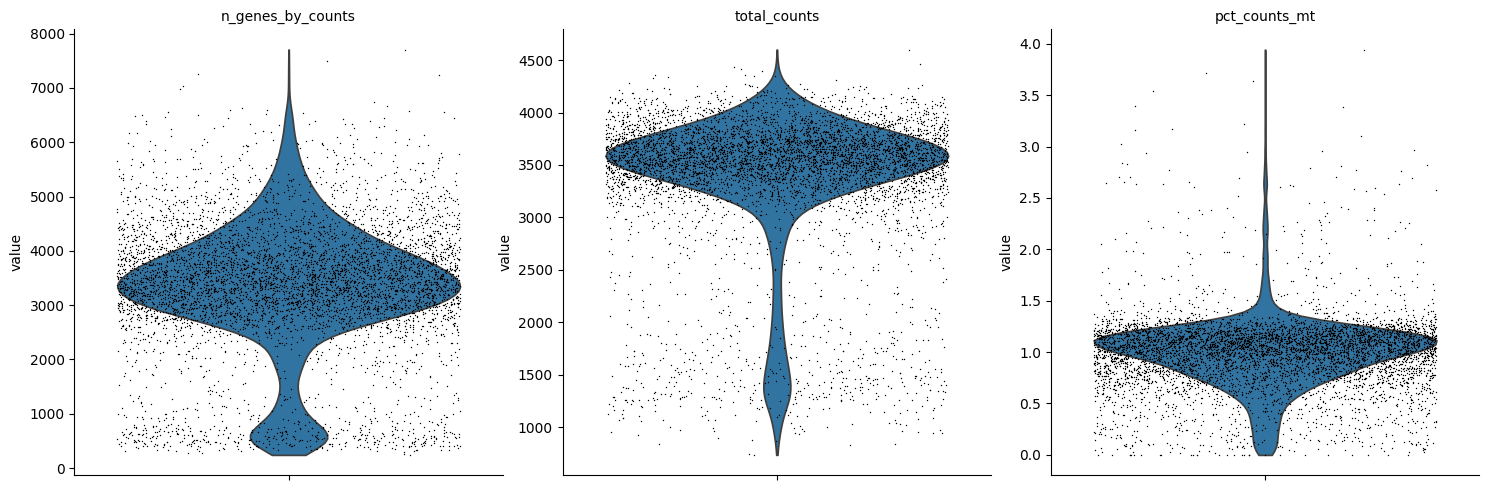

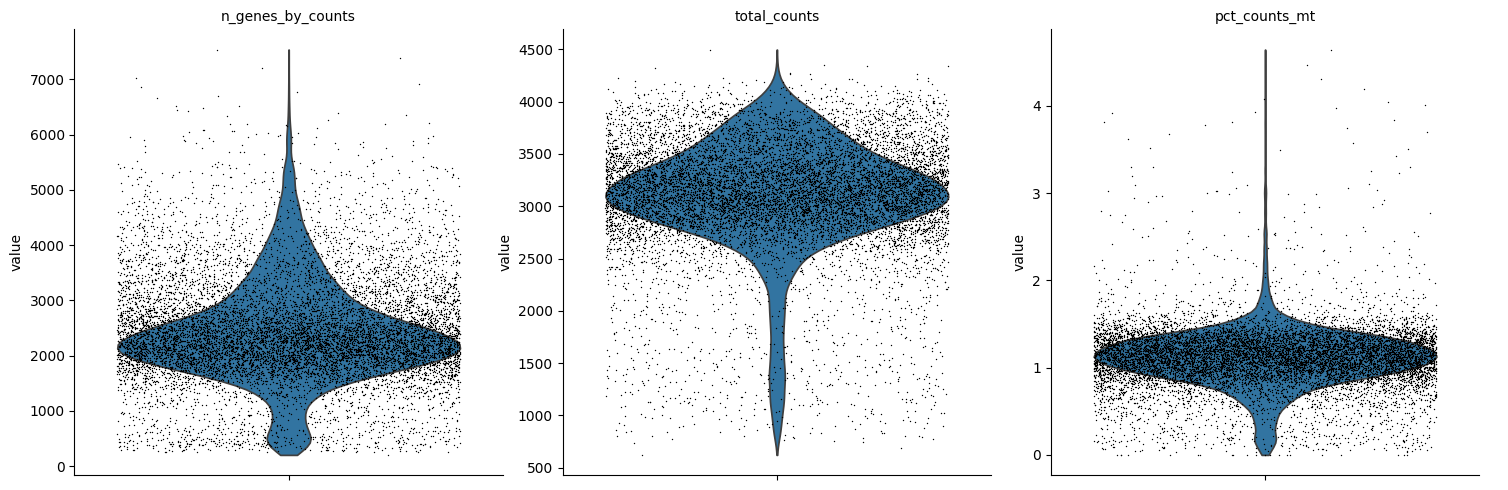

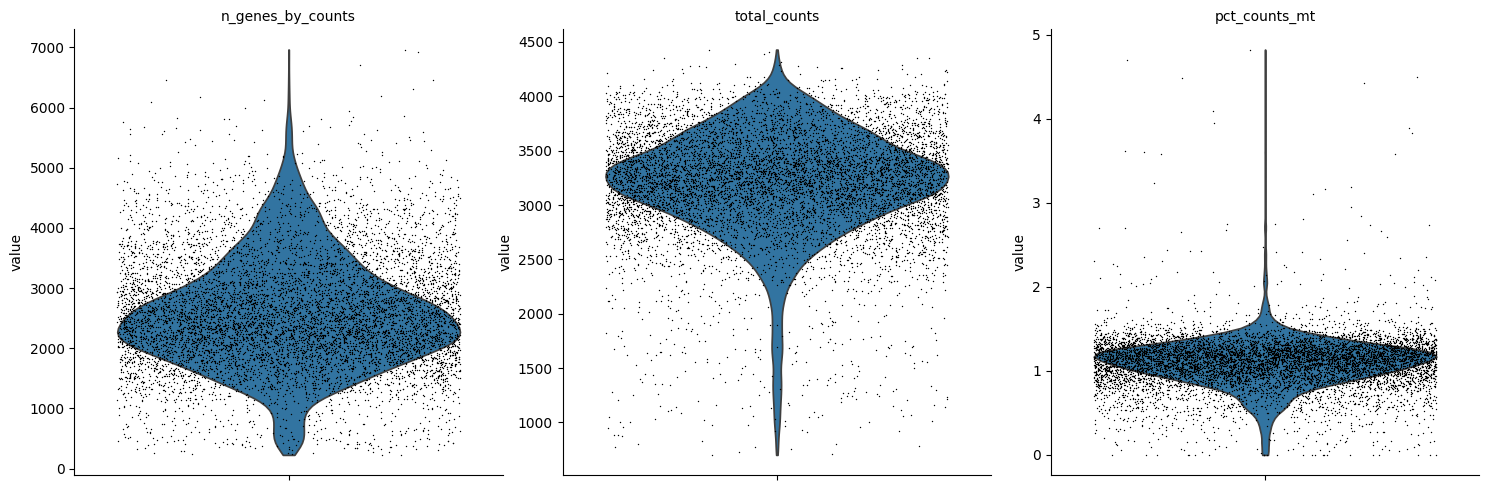

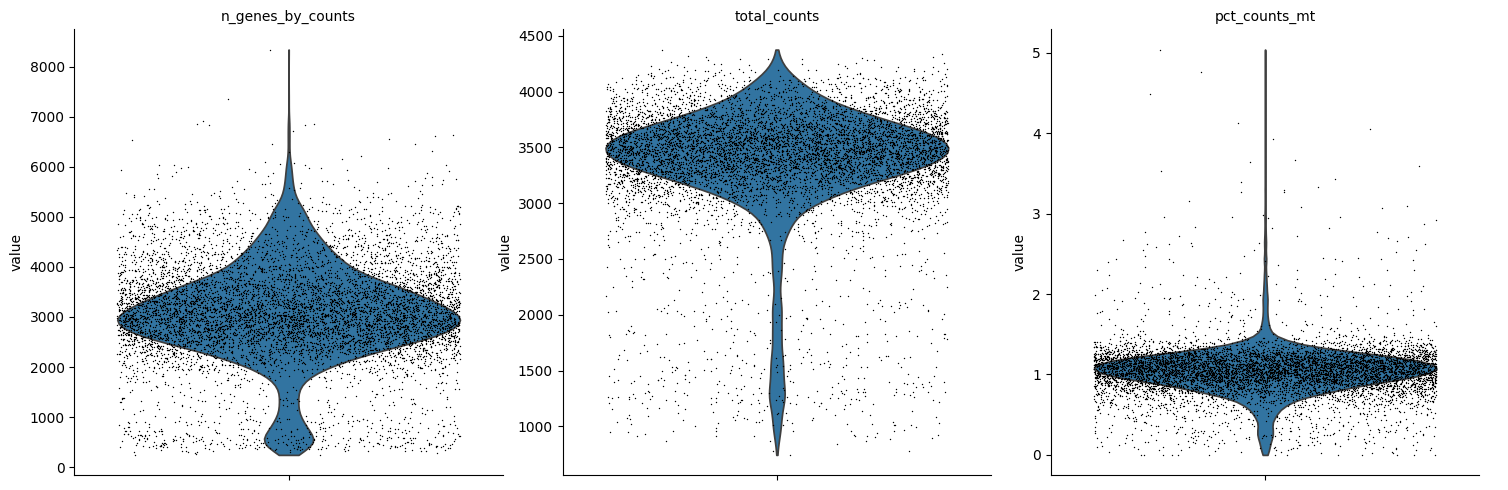

In [15]:
for f in glob.glob(f"{WORK_DIR}/adata/leiden_clustered/*.h5ad"):
    if "ALL.h5ad" in f:
        continue
    adata = sc.read_h5ad(f)
    
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
    )
    
    sc.pl.violin(
        adata,
        ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
        xlabel=f,
    )

### 1.2 filter doublet

In [12]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/doublet_filtered

In [41]:
%%bash
qsub /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/doublet_filtered/test.sh

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 111009548 ("test.sh") has been submitted


In [7]:
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/leiden_clustered/ALL.h5ad")
# adata

### 1.3 re-label

/tmp/ipykernel_1859511/2970865849.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/tmp/ipykernel_1859511/2970865849.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/an

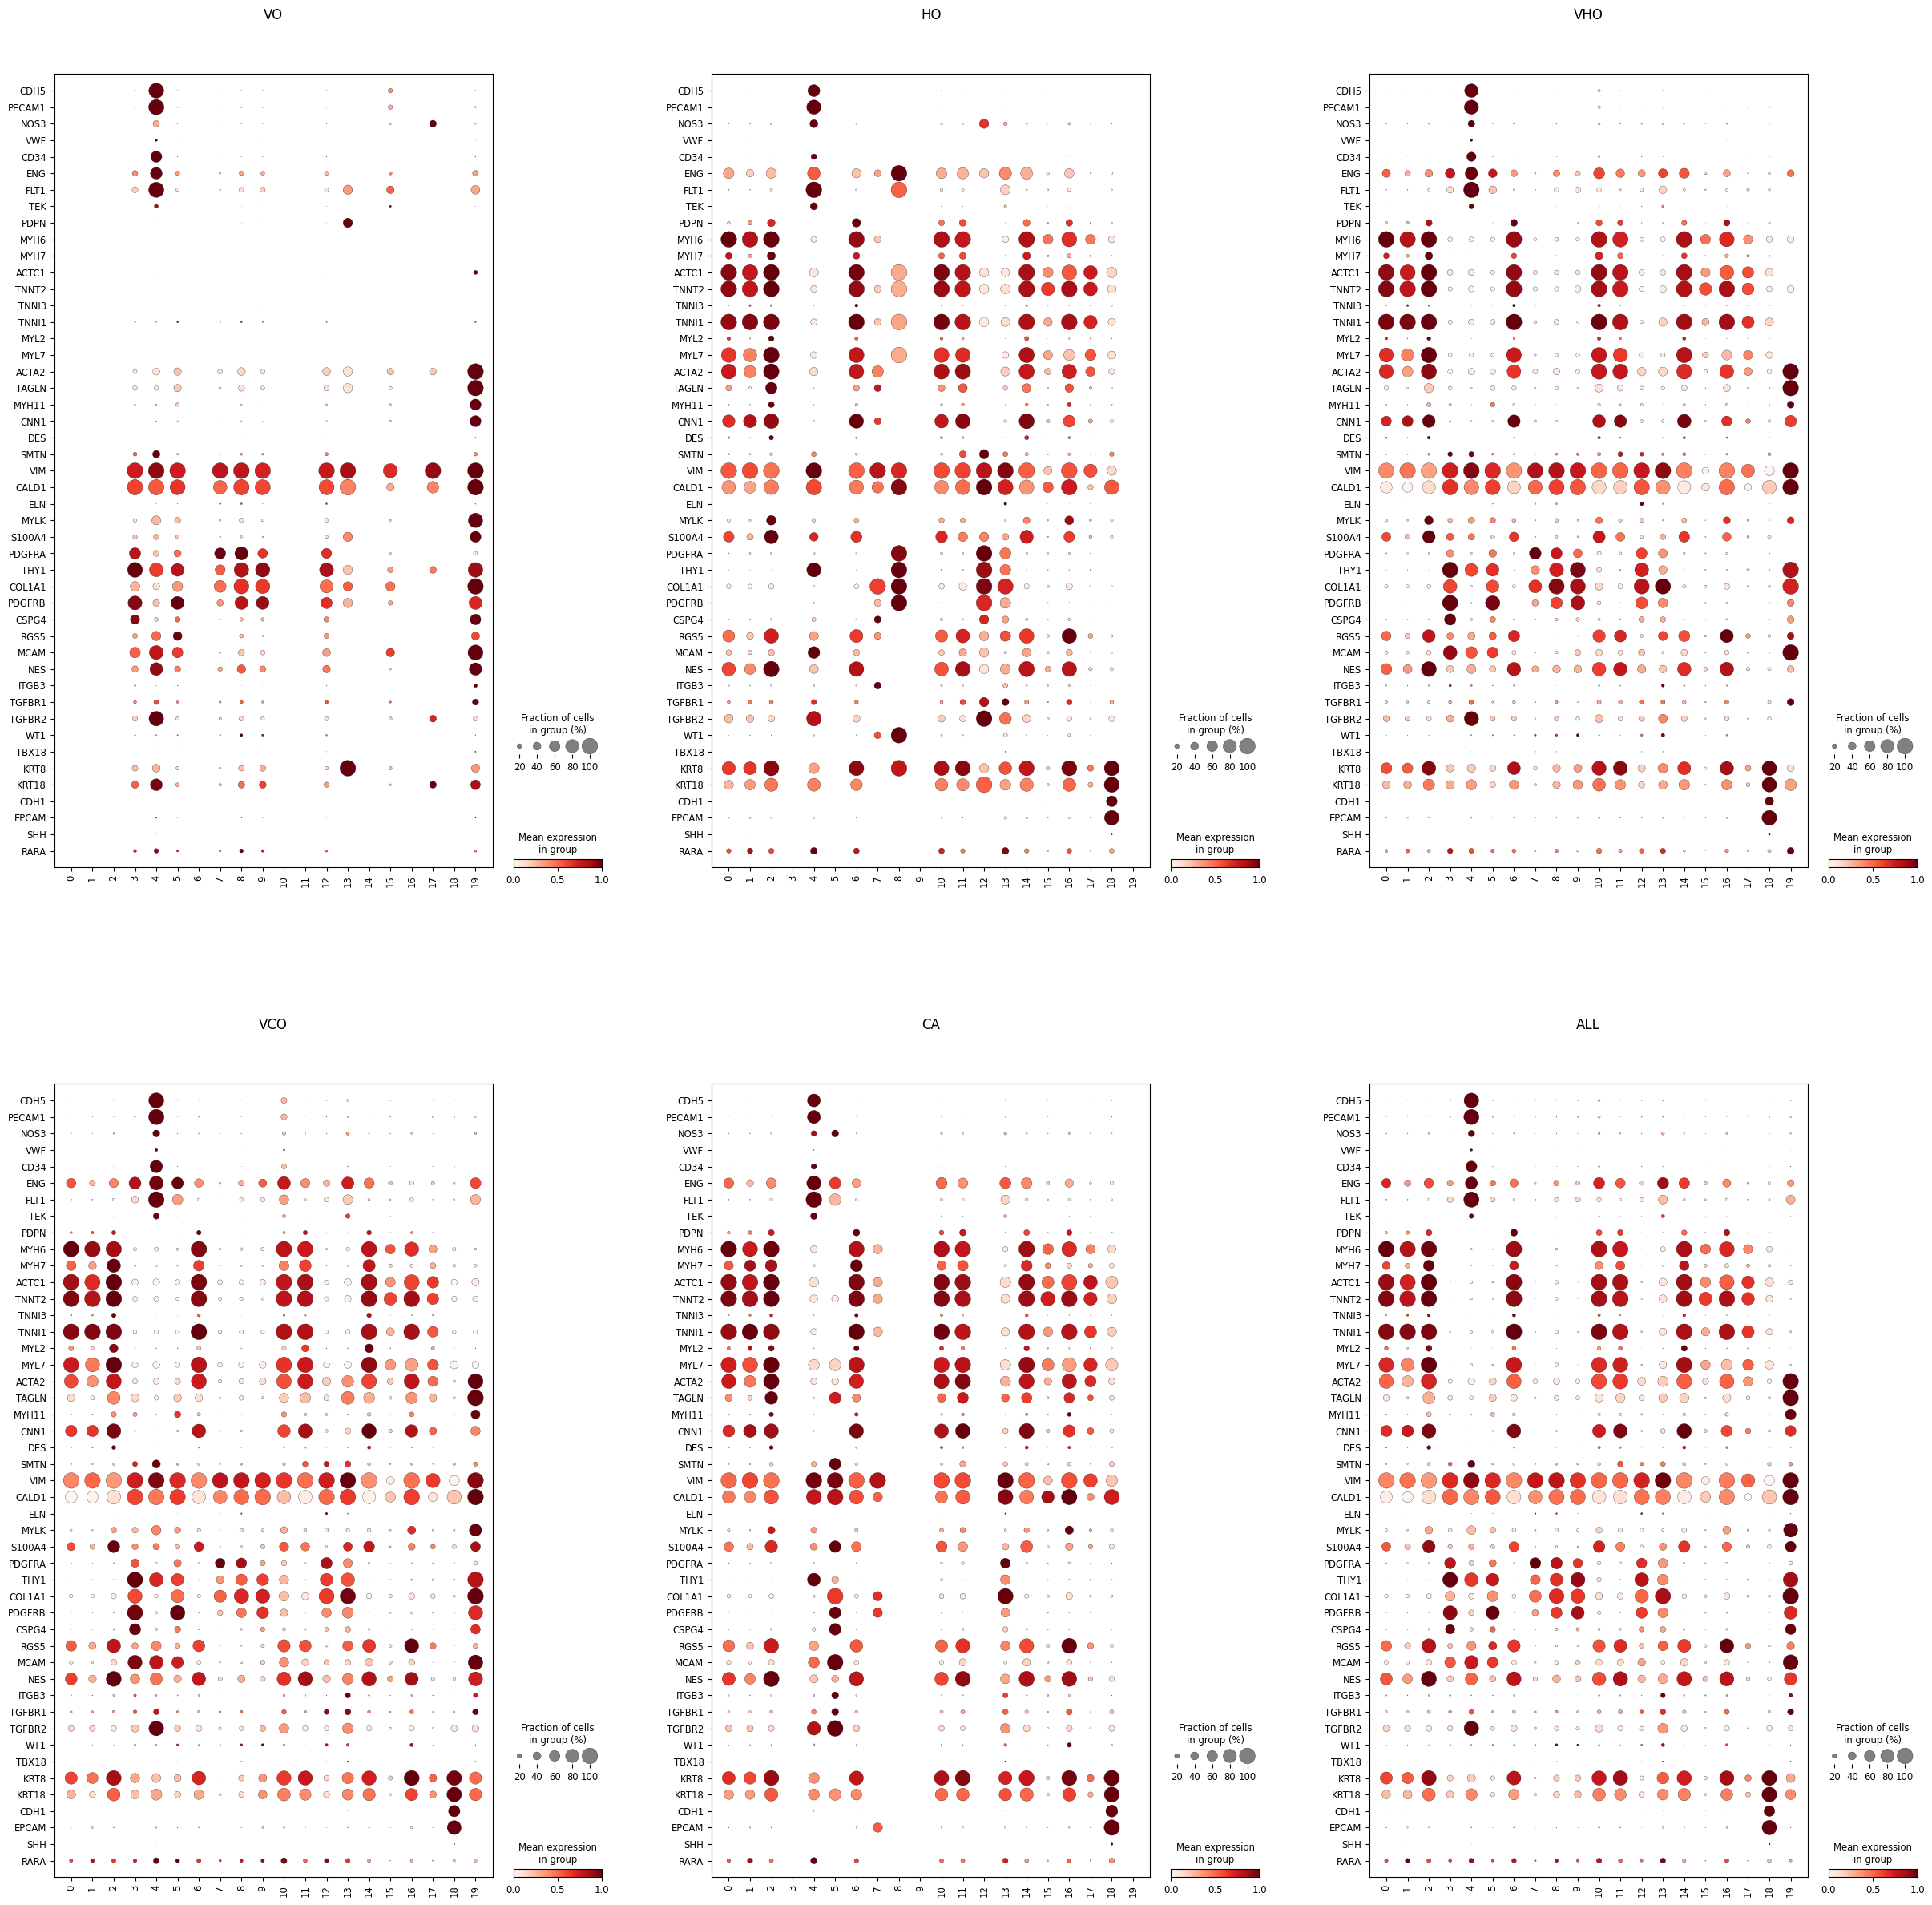

In [4]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/doublet_filtered/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_leiden.png')
plt.show()

In [5]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'PR',
    '4': 'EN',
    '5': 'PR',
    '6': 'CM',
    '7': 'FB',
    '8': 'FB',
    '9': 'FB',
    '10': 'CM',
    '11': 'CM',
    '12': 'FB',
    '13': 'SM',
    '14': 'CM',
    '15': 'CME',
    '16': 'CM',
    '17': 'CME',
    '18': 'EP',
    '19': 'SM',
}

In [6]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/uamps

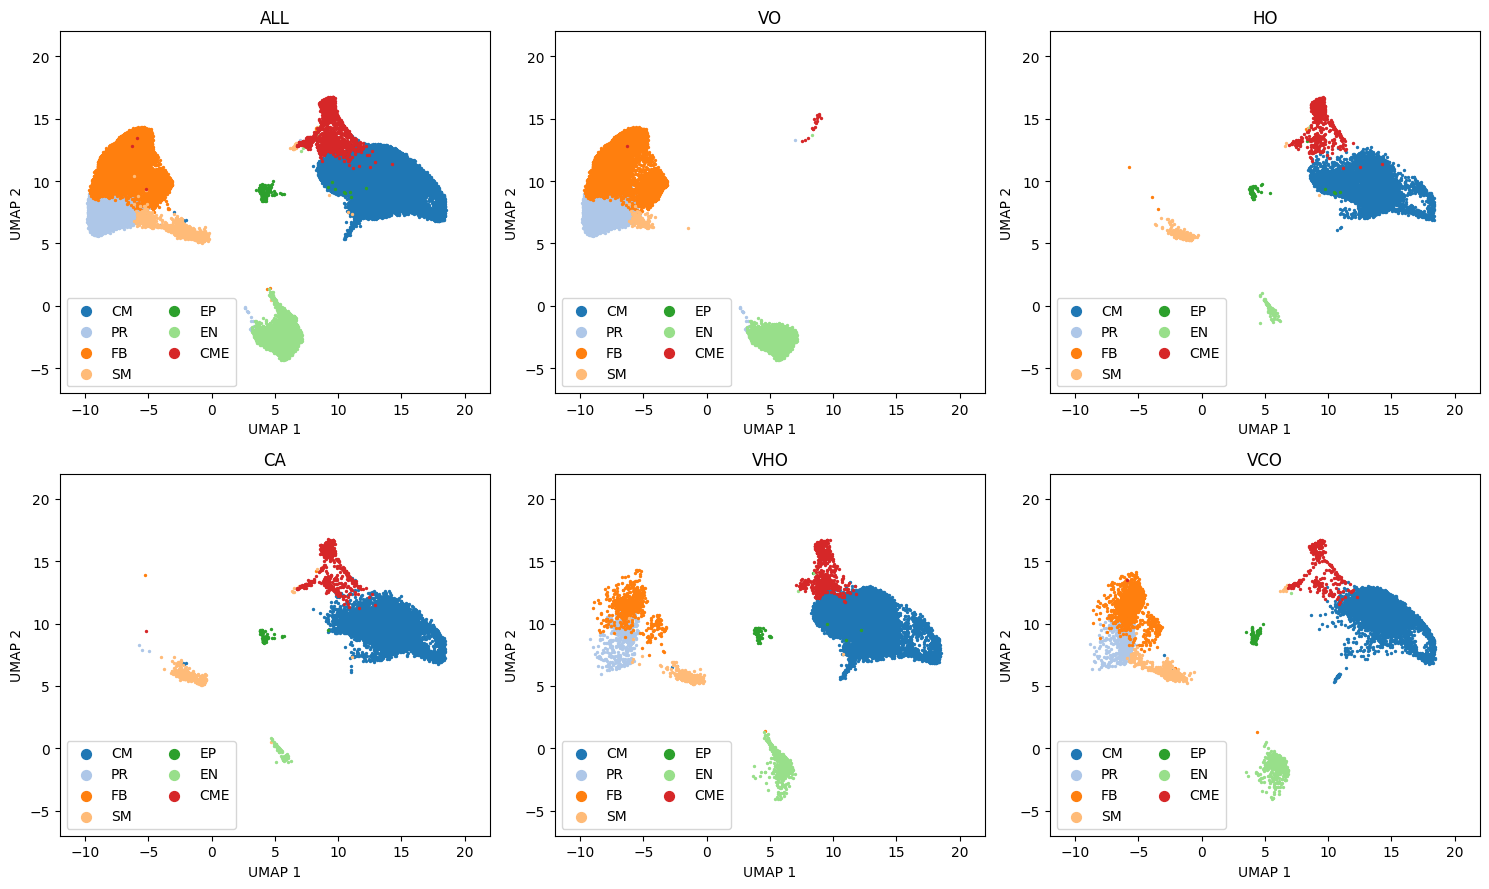

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cell_types = ['CM','PR','FB','SM','EP','EN','CME']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/doublet_filtered/{sample}.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    
    adata.obs['batch'] = adata.obs['batch'].astype('str')
    adata.obs['batch'] = adata.obs['batch'].map(batch_mapper)
    adata.obs['batch'] = adata.obs['batch'].astype('category')
    
    adata.write(f'{WORK_DIR}/adata/cell_type_labelled/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='lower left', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 22])
    axs[i].set_ylim([-7, 22])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/cell_type_labelled.png')
plt.show()

### 1.4

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# adata = sc.read_h5ad(f'{WORK_DIR}/adata/doublet_filtered/ALL.h5ad')
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/CM.h5ad")

# Function to sample distances based on gene expression
def sample_expression_distances(adata, cluster1, cluster2, n_samples=5000, use_raw=False):
    cells1 = adata.obs[adata.obs['cell_type_subcluster'] == str(cluster1)].index
    cells2 = adata.obs[adata.obs['cell_type_subcluster'] == str(cluster2)].index

    if len(cells1) == 0 or len(cells2) == 0:
        return []

    sampled1 = np.random.choice(cells1, n_samples, replace=True)
    sampled2 = np.random.choice(cells2, n_samples, replace=True)

    X = adata.raw.X if use_raw else adata.X

    X1 = X[adata.obs_names.get_indexer(sampled1)]
    X2 = X[adata.obs_names.get_indexer(sampled2)]

    if hasattr(X1, "toarray"):  # If sparse
        X1 = X1.toarray()
        X2 = X2.toarray()

    distances = np.linalg.norm(X1 - X2, axis=1)
    return distances

# Loop through cluster pairs
clusters = ['CM_0', 'CM_1', 'CM_2', 'CM_3', 'CM_4', 'CM_5', 'CM_6', 'CM_7']
results = []

for i in range(0, len(clusters)):
    for j in range(0, len(clusters)):
        c1, c2 = clusters[i], clusters[j]
        dists = sample_expression_distances(adata, c1, c2, use_raw=False)
        results.extend([(c1, c2, d) for d in dists])

# Convert to DataFrame for plotting
df = pd.DataFrame(results, columns=['Cluster1', 'Cluster2', 'Distance'])
df['Pair'] = df['Cluster1'] + '-' + df['Cluster2']

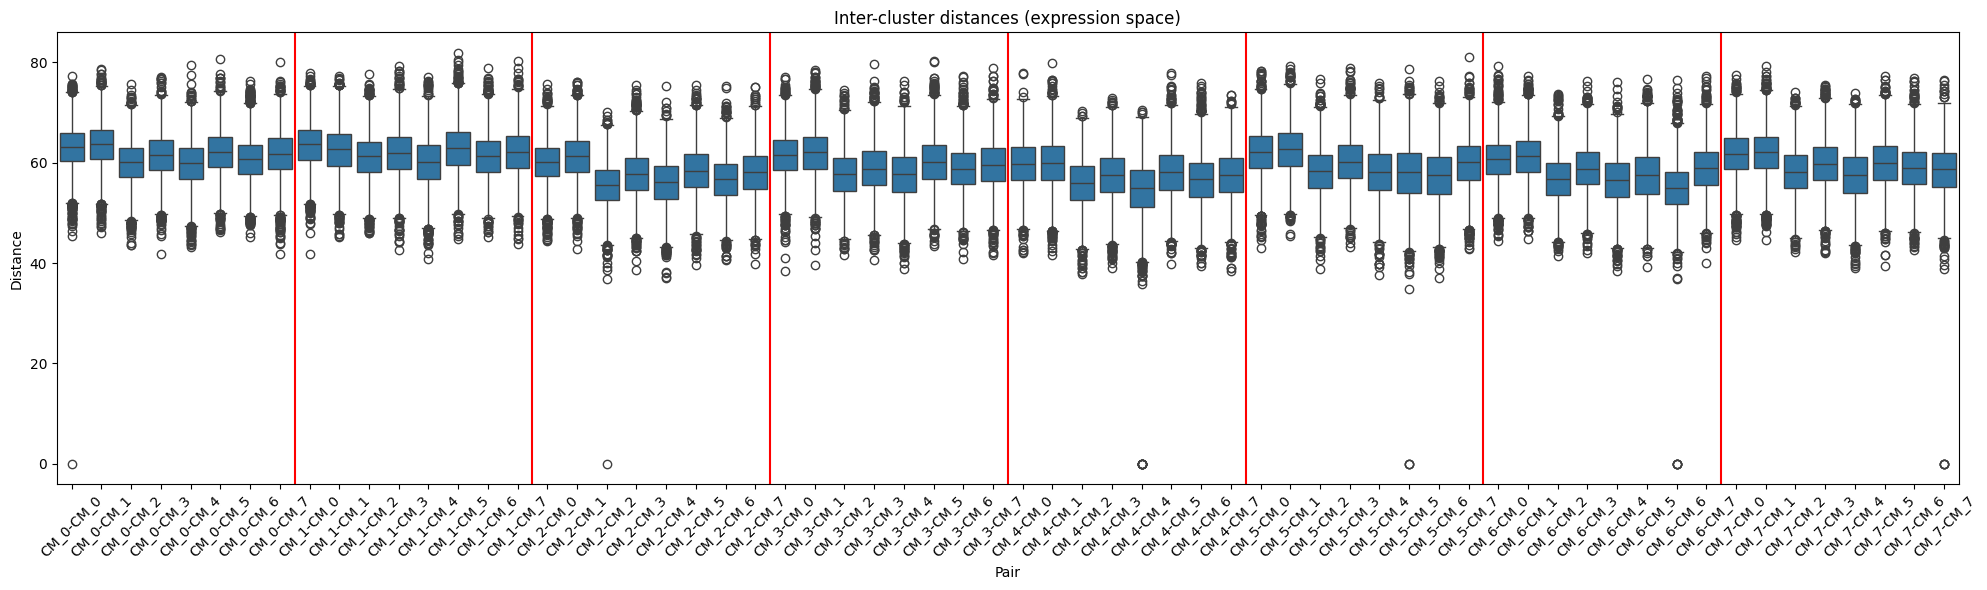

In [26]:
plt.figure(figsize=(20, 6))
sns.boxplot(x='Pair', y='Distance', data=df)
plt.xticks(rotation=45)
plt.title('Inter-cluster distances (expression space)')
for i in range(1, len(clusters)):
    plt.axvline(i * len(clusters) - 0.5, color="r")
plt.tight_layout()
plt.show()

In [42]:
dist_matrix ** 2

,CM_0,CM_1,CM_2,CM_3,CM_4,CM_5,CM_6,CM_7
CM_0,0.000000,4041.249137,3606.109157,3776.960595,3555.599637,3858.173915,3667.041119,3813.396057
CM_1,4041.249137,0.000000,3742.282519,3839.349232,3587.911928,3932.081826,3761.160439,3847.705605
CM_2,3606.109157,3742.282519,0.000000,3322.137781,3114.996833,3393.002060,3213.486928,3377.033749
CM_3,3776.960595,3839.349232,3322.137781,0.000000,3306.860246,3633.675953,3467.452911,3570.604078
CM_4,3555.599637,3587.911928,3114.996833,3306.860246,0.000000,3378.381258,3184.422430,3315.604657
CM_5,3858.173915,3932.081826,3393.002060,3633.675953,3378.381258,0.000000,3309.077963,3594.009452
CM_6,3667.041119,3761.160439,3213.486928,3467.452911,3184.422430,3309.077963,0.000000,3470.039769
CM_7,3813.396057,3847.705605,3377.033749,3570.604078,3315.604657,3594.009452,3470.039769,0.000000


/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


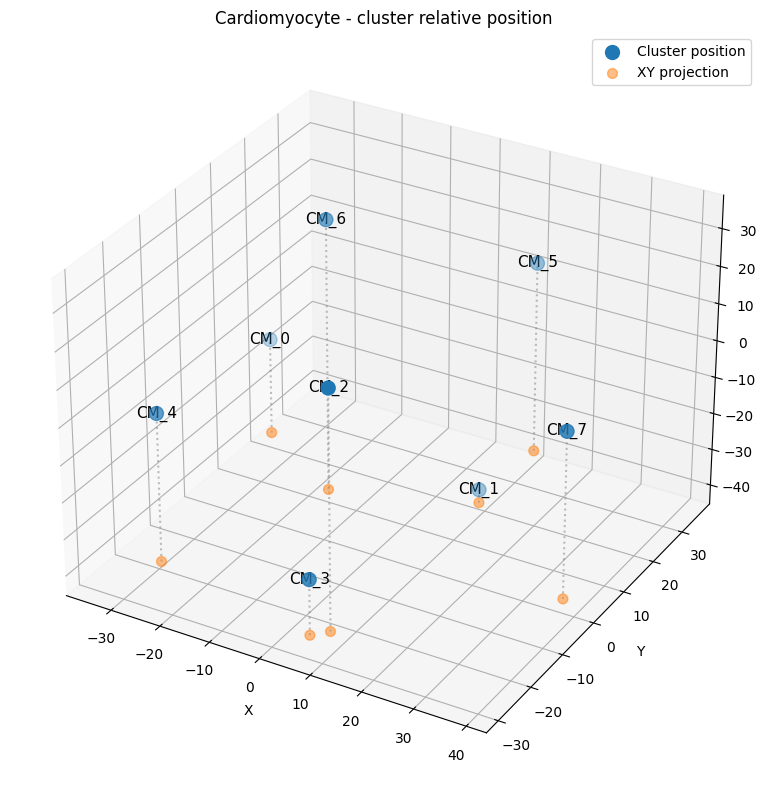

In [37]:
mean_distances = df.groupby(['Cluster1', 'Cluster2'])['Distance'].mean().reset_index()

clusters = sorted(set(mean_distances['Cluster1']) | set(mean_distances['Cluster2']))

# Create empty square matrix
dist_matrix = pd.DataFrame(index=clusters, columns=clusters, dtype=float)

# Fill in the matrix with the averaged distances
for _, row in mean_distances.iterrows():
    c1, c2, dist = row['Cluster1'], row['Cluster2'], row['Distance']
    dist_matrix.loc[c1, c2] = dist
    dist_matrix.loc[c2, c1] = dist  # ensure symmetry

# Fill diagonal with 0
np.fill_diagonal(dist_matrix.values, 0)

from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

# Perform MDS with 3 components
mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
coords_3d = mds.fit_transform(dist_matrix)

# Wrap into DataFrame
coords_df_3d = pd.DataFrame(coords_3d, index=clusters, columns=['x', 'y', 'z'])

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original 3D points
ax.scatter(coords_df_3d['x'], coords_df_3d['y'], coords_df_3d['z'], s=100, label='Cluster position')

# Plot projections onto x-y plane (z=0)
ax.scatter(coords_df_3d['x'], coords_df_3d['y'], zs=-40, zdir='z', s=50, alpha=0.5, label='XY projection')

# Draw dotted lines from point to projection
for cluster, (x, y, z) in coords_df_3d.iterrows():
    ax.plot([x, x], [y, y], [-40, z], linestyle='dotted', color='gray', alpha=0.5)
    ax.text(x, y, z, cluster, fontsize=11, ha='center', va='center')

# Labels and title
ax.set_title('Cardiomyocyte - cluster relative position')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Split cell types and recluster

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_split
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_subclustered

In [24]:
cell_types = ['CM','PR','FB','SM','EP','EN','CME']
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

In [5]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for ct in cell_types:
    adata = adata_all[adata_all.obs['cell_type'] == ct]
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

### 2.1 Cardiomyocytes - aim for 4 clusters

In [7]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.3)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_290097/3310301907.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGAAGGGAT-1-0    2
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    3
TTTGTTGAGGGTACGT-1-4    3
TTTGTTGTCATGCCGG-1-4    5
TTTGTTGTCGTTGCCT-1-4    6
Name: leiden, Length: 25365, dtype: category
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']

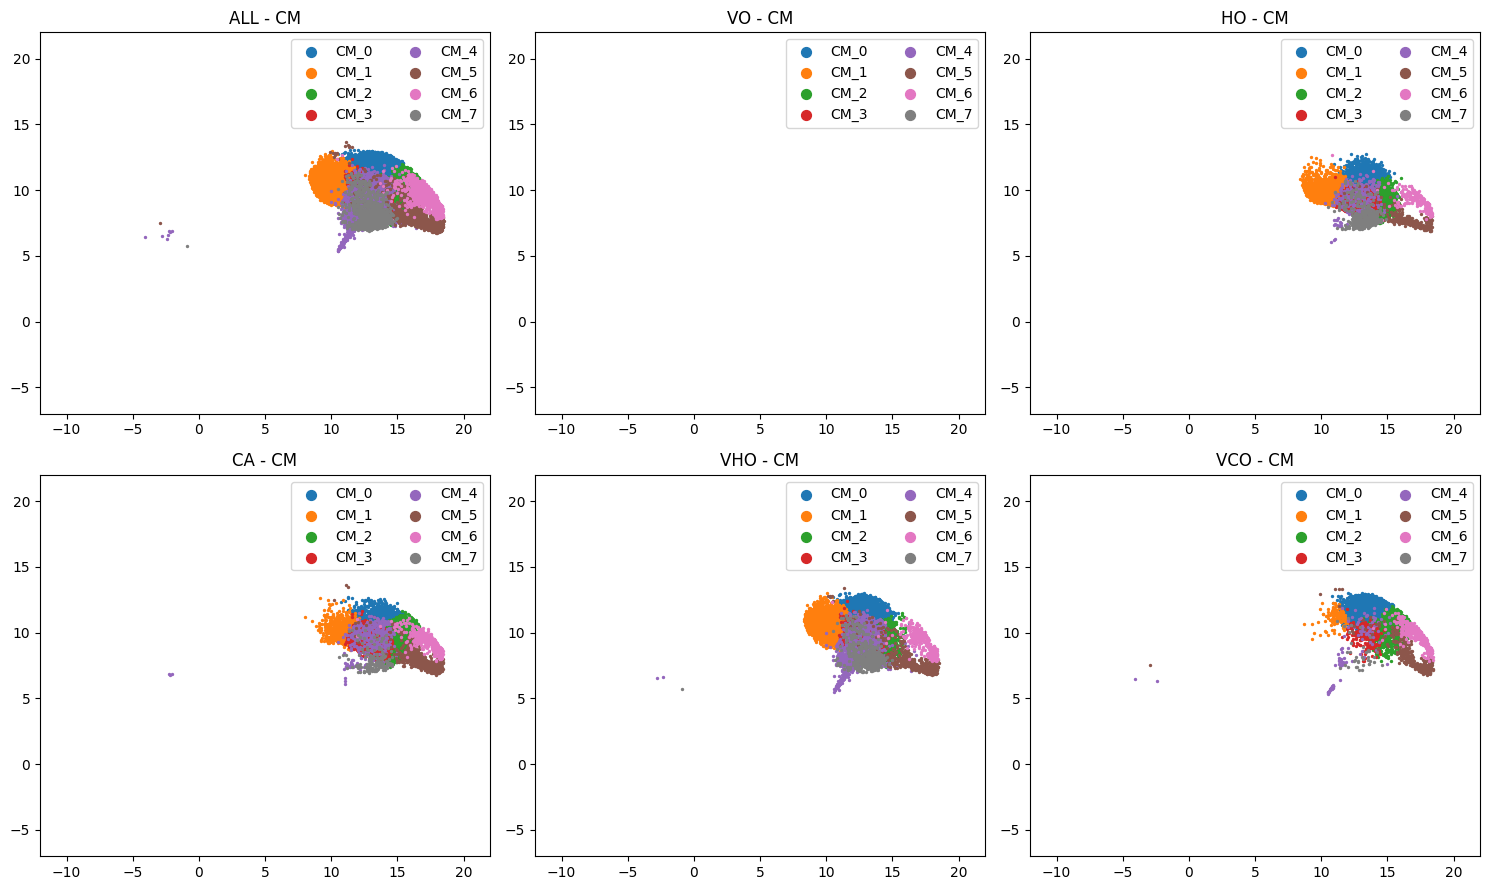

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

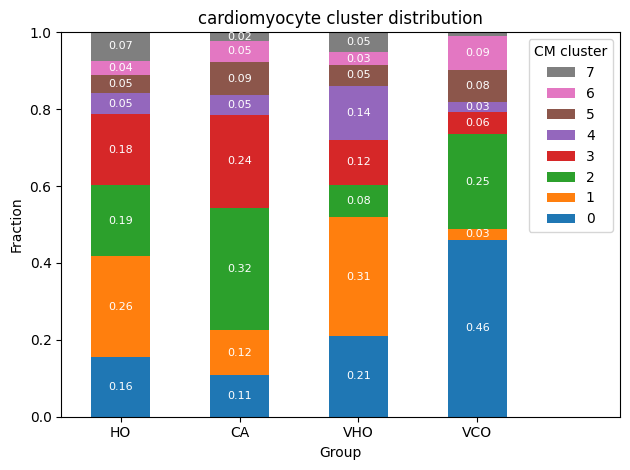

In [14]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

# df.plot(kind='bar', stacked=True)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
# # plt.title('Fracti')
# plt.legend(title='CM cluster')
# plt.ylim((0,1))
# plt.xlim((-0.5, 4.2))
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title("cardiomyocyte cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='CM cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

In [10]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


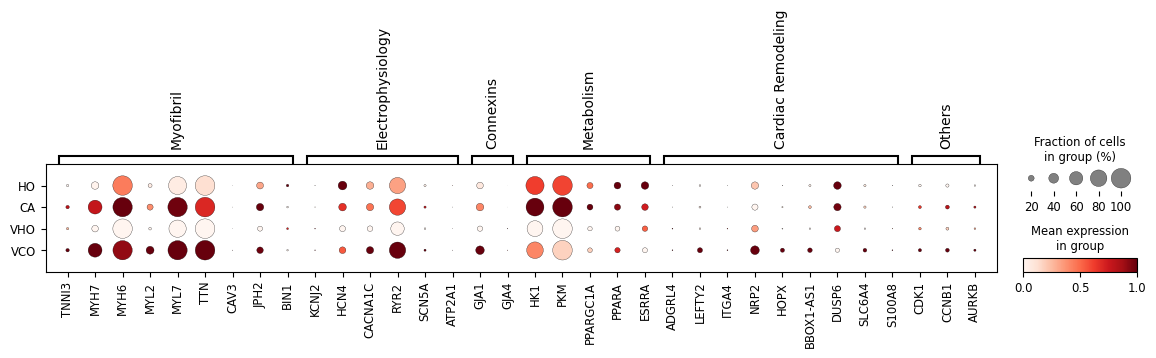

In [20]:
marker_dict = {
    "Myofibril": ["TNNI3", "MYH7", "MYH6", "MYL2", "MYL7", "TTN", "CAV3", "JPH2", "BIN1"], 
    "Electrophysiology": ["KCNJ2", "HCN4", "CACNA1C", "RYR2", "SCN5A", "ATP2A1"], 
    "Connexins": ["GJA1", "GJA4"], 
    "Metabolism": ["HK1", "PKM", "PPARGC1A", "PPARA", "ESRRA"], 
    "Cardiac Remodeling": ["ADGRL4", "LEFTY2", "ITGA4", "NRP2", "HOPX", "BBOX1-AS1", "DUSP6", "SLC6A4", "S100A8"], 
    "Others": ["CDK1", "CCNB1", "AURKB"], 
}

adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['HO', 'CA', 'VHO', 'VCO'], ordered=True)

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var")

In [22]:
adata.obs['cell_type']

AAACCCAAGAAGGGAT-1-0    CM
AAACCCAAGTCAGGGT-1-0    CM
AAACCCACATCCAACA-1-0    CM
AAACCCAGTAGATGTA-1-0    CM
AAACCCAGTAGTACGG-1-0    CM
                        ..
TTTGTTGAGACTGGGT-1-4    CM
TTTGTTGAGATTGACA-1-4    CM
TTTGTTGAGGGTACGT-1-4    CM
TTTGTTGTCATGCCGG-1-4    CM
TTTGTTGTCGTTGCCT-1-4    CM
Name: cell_type, Length: 25365, dtype: category
Categories (1, object): ['CM']

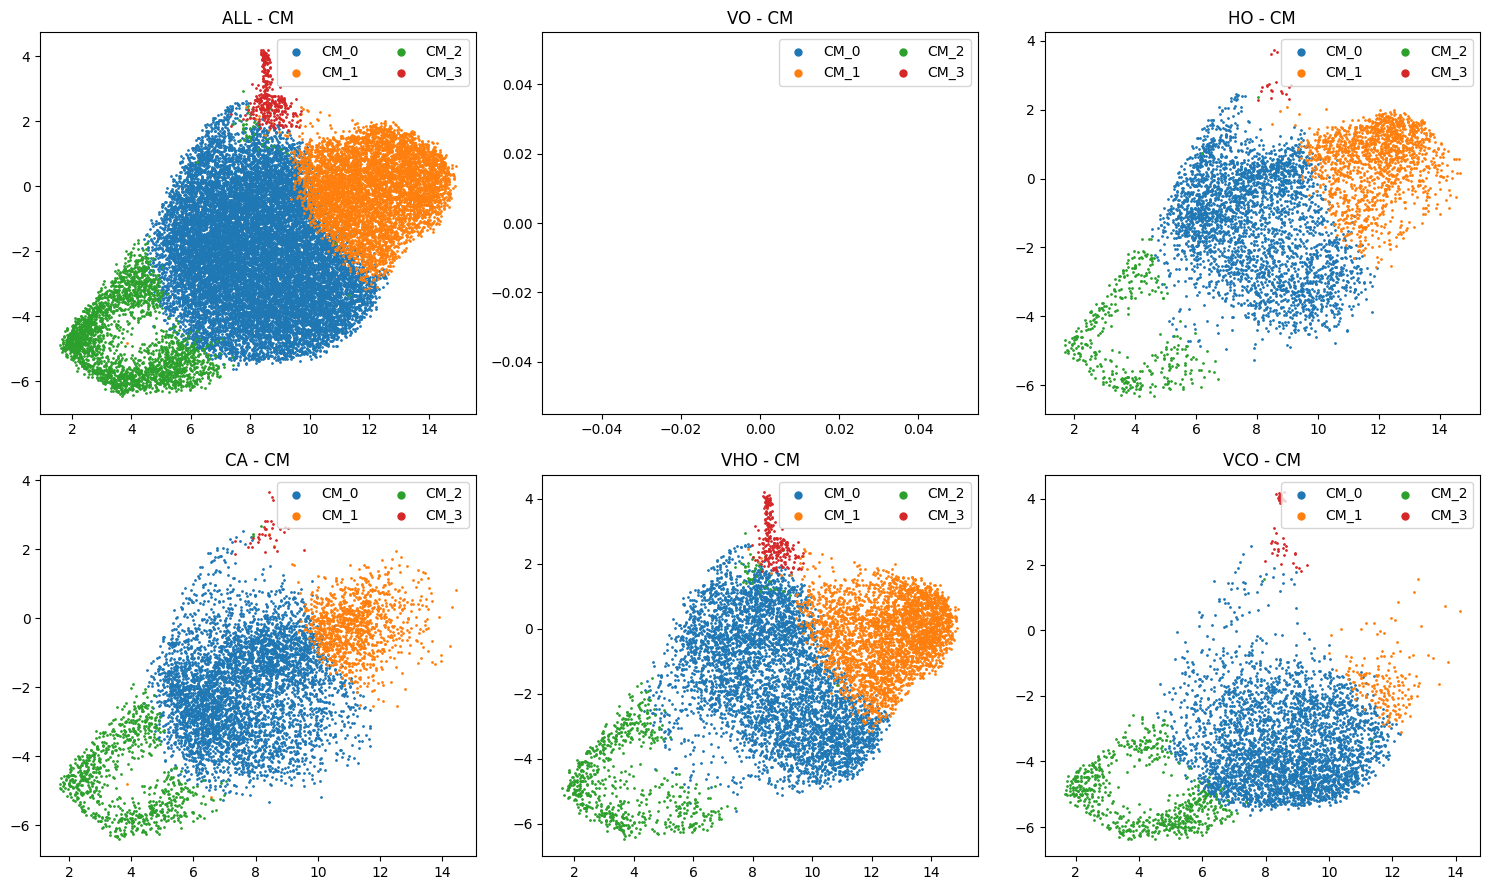

In [27]:
# n_neighbors = 1000
# sc.tl.pca(adata, svd_solver='arpack', n_comps=50, random_state=42)
# sc.pp.neighbors(adata, n_pcs=50, n_neighbors=n_neighbors, random_state=42)
sc.tl.leiden(adata, resolution=0.3)
# sc.tl.umap(adata)

fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=1)
    
    # ax.set_xlim([-10, 10])
    # ax.set_ylim([-10, 15])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.reembed.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


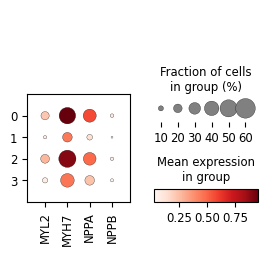

In [28]:
marker_dict = ['MYL2', 'MYH7', 'NPPA', 'NPPB']
sc.pl.dotplot(adata, marker_dict, groupby="leiden")

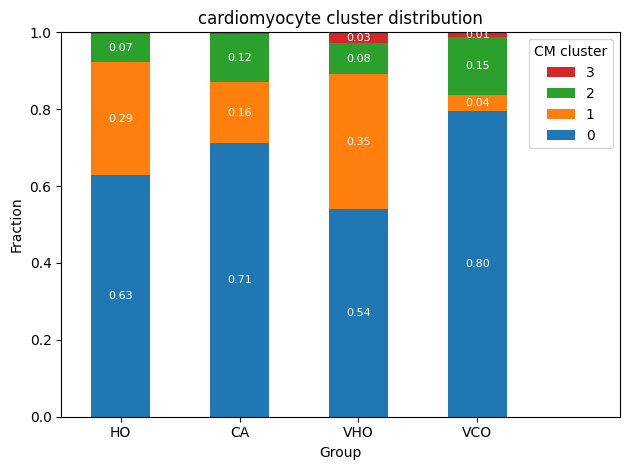

In [29]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['leiden'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

# df.plot(kind='bar', stacked=True)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
# # plt.title('Fracti')
# plt.legend(title='CM cluster')
# plt.ylim((0,1))
# plt.xlim((-0.5, 4.2))
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title("cardiomyocyte cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='CM cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

### 2.2 Fibroblast

In [10]:
ct = "FB"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.1)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_1096662/2447842915.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCATCATTGCGA-1-0    1
AAAGGATAGCGCCTAC-1-0    1
AAAGGGCTCTCGGTAA-1-0    0
AAAGGTAGTCCACAGC-1-0    3
AAAGTGATCTCATAGG-1-0    2
                       ..
CAGGGCTCAAGCACAG-1-4    1
CCTCATGGTCTGTGGC-1-4    0
CGCATAATCATTGCCC-1-4    3
CTCCTCCAGTCCTGTA-1-4    0
TCTACATAGGTTATAG-1-4    0
Name: leiden, Length: 9737, dtype: category
Categories (4, object): ['0', '1', '2', '3']

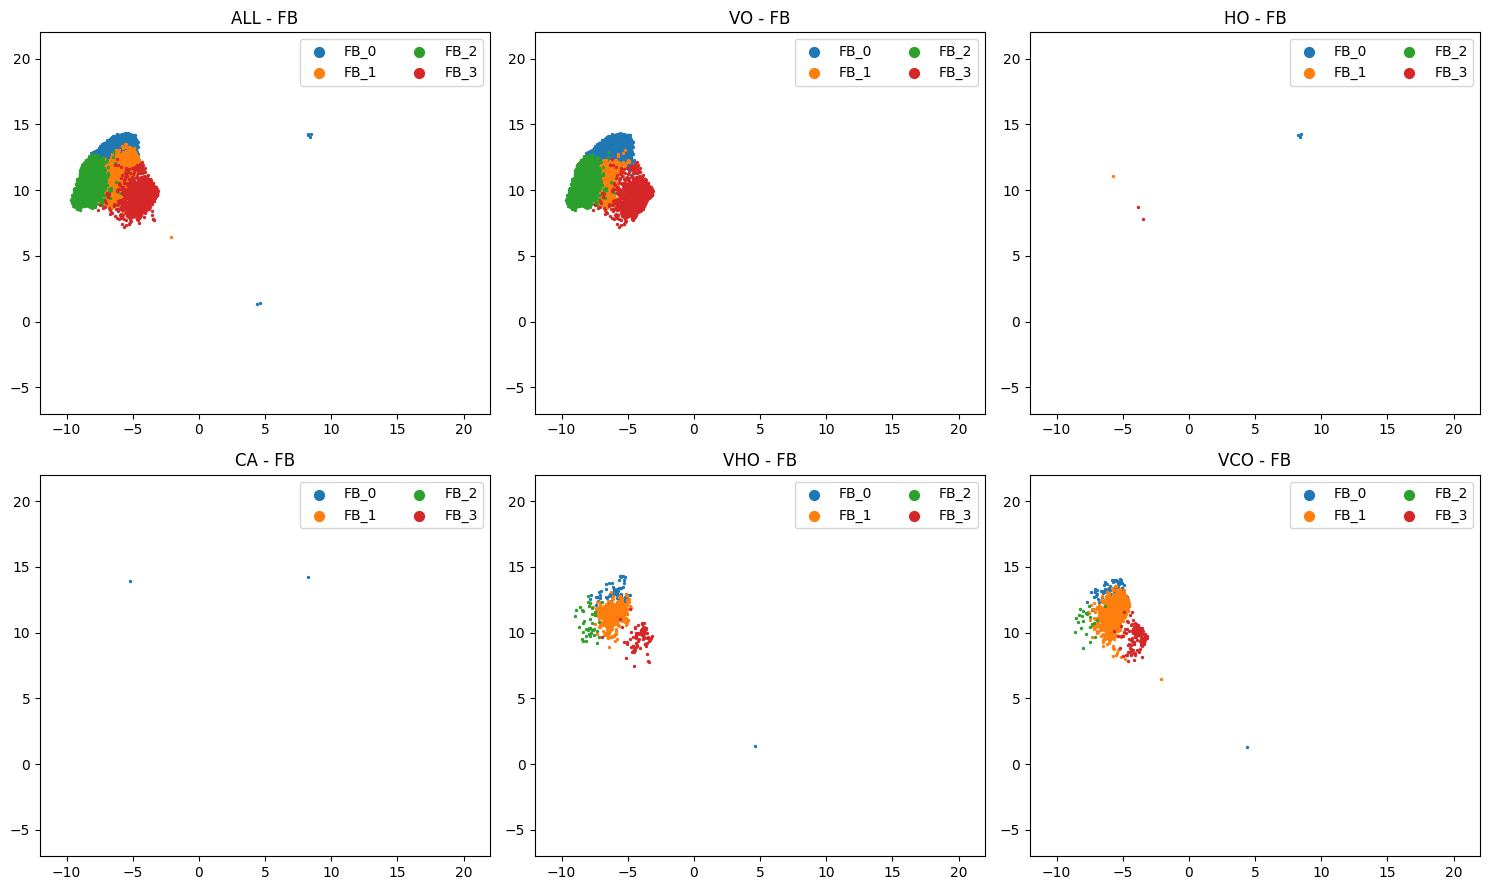

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [18]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


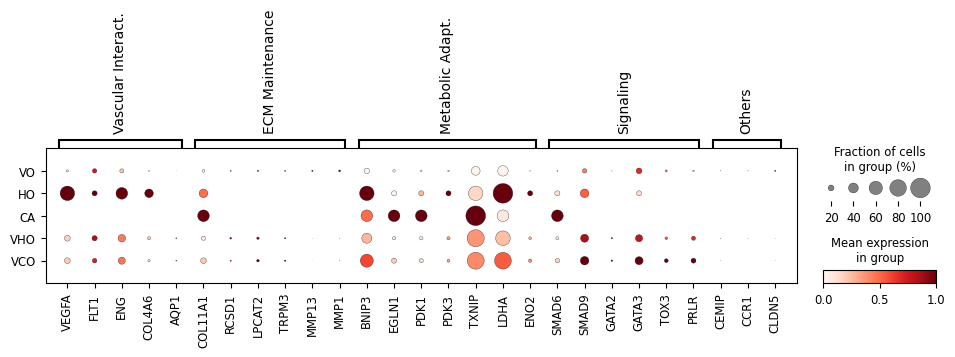

In [12]:
marker_dict = {
    "Vascular Interact.": ["VEGFA", "FLT1", "ENG", "COL4A6", "AQP1"], 
    "ECM Maintenance": ["COL11A1", "RCSD1", "LPCAT2", "TRPM3", "MMP13", "MMP1"], 
    "Metabolic Adapt.": ["BNIP3", "EGLN1", "PDK1", "PDK3", "TXNIP", "LDHA", "ENO2"], 
    "Signaling": ["SMAD6", "SMAD9", "GATA2", "GATA3", "TOX3", "PRLR"],
    "Others": ["CEMIP", "CCR1", "CLDN5"]
}

adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var")

In [ ]:
marker_dict = {
    "Vascular Interact.": ["VEGFA", "FLT1", "ENG", "COL4A6", "AQP1"], 
    "ECM Maintenance": ["COL11A1", "RCSD1", "LPCAT2", "TRPM3", "MMP13", "MMP1"], 
    "Metabolic Adapt.": ["BNIP3", "EGLN1", "PDK1", "PDK3", "TXNIP", "LDHA", "ENO2"], 
    "Signaling": ["SMAD6", "SMAD9", "GATA2", "GATA3", "TOX3", "PRLR"],
    "Others": ["CEMIP", "CCR1", "CLDN5"]
}

adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var")

### 2.3 endothelial cells

In [4]:
ct = "EN"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.5)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_1096662/1151569868.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCACATCCTTGC-1-0    2
AAAGAACAGGGCAATC-1-0    2
AAAGGATGTCAAGCGA-1-0    2
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    2
TTCGCTGCAAGTGGGT-1-4    2
TTTACTGGTAGACACG-1-4    2
TTTCAGTAGCGCTGAA-1-4    2
TTTGATCAGCGCACAA-1-4    2
Name: leiden, Length: 4160, dtype: category
Categories (4, object): ['0', '1', '2', '3']

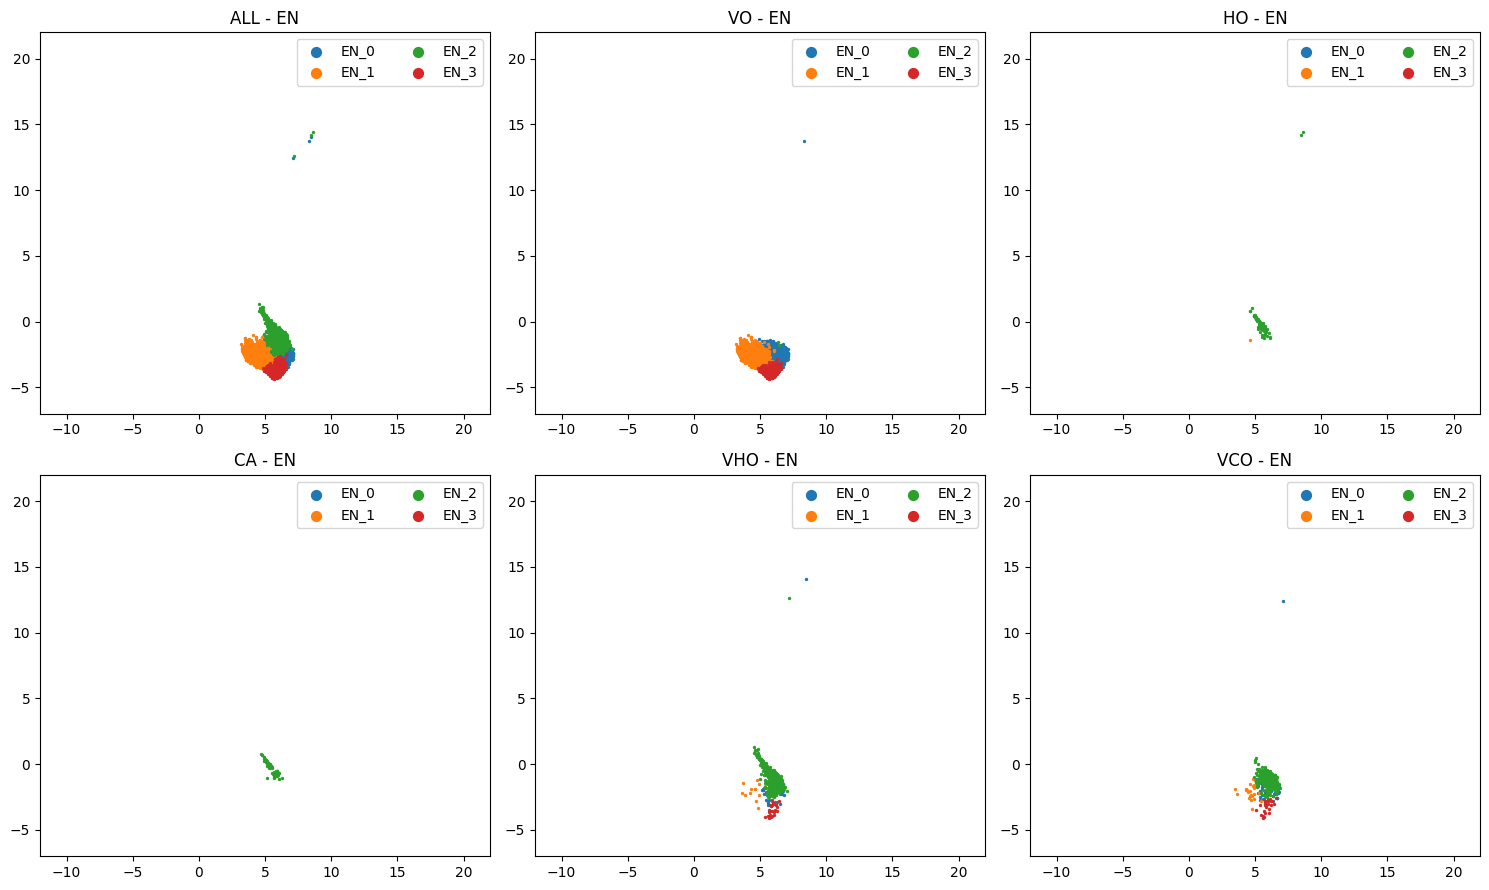

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [13]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [14]:
ct = "EN"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.2)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_470292/211587228.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCACATCCTTGC-1-0    0
AAAGAACAGGGCAATC-1-0    0
AAAGGATGTCAAGCGA-1-0    0
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    0
TTCGCTGCAAGTGGGT-1-4    0
TTTACTGGTAGACACG-1-4    0
TTTCAGTAGCGCTGAA-1-4    0
TTTGATCAGCGCACAA-1-4    0
Name: leiden, Length: 4160, dtype: category
Categories (2, object): ['0', '1']

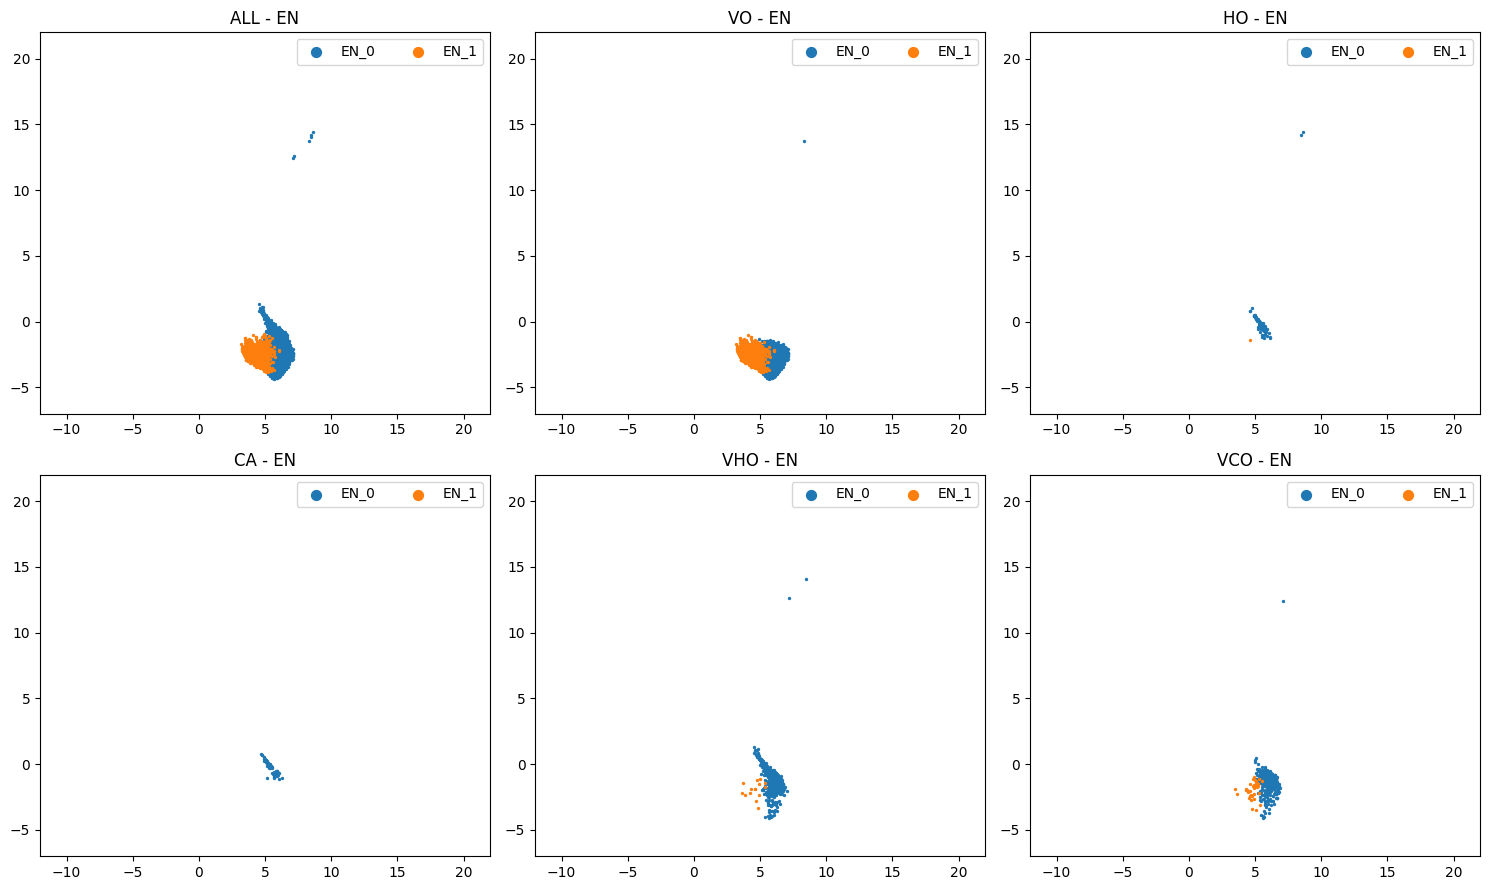

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 22])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.2_clusters.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


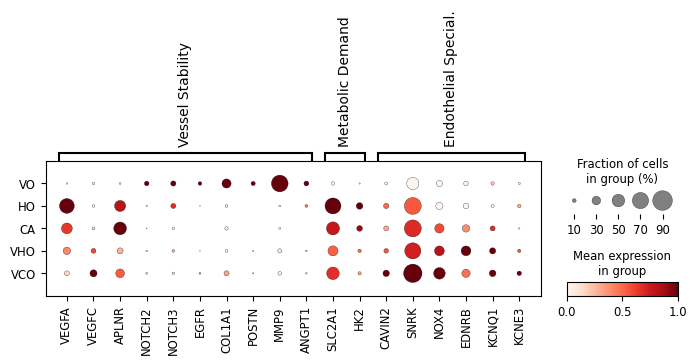

In [8]:
marker_dict = {
    "Vessel Stability": ["VEGFA", "VEGFC", "APLNR", "NOTCH2", "NOTCH3", "EGFR", "COL1A1", "POSTN", "MMP9", "ANGPT1"], 
    "Metabolic Demand": ["SLC2A1", "HK2"], 
    "Endothelial Special.": ["CAVIN2", "SNRK", "NOX4", "EDNRB", "KCNQ1", "KCNE3"], 
}

adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var")

### 2.4 don't subcluster other celltypes for now

In [22]:
cts = ['PR','SM','EP','CME']

for ct in cts:
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
    adata.obs['cell_type_subcluster'] = adata.obs['cell_type'].copy()
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.5 rearrange according to experiment

In [23]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect

In [24]:
cell_type_subcluster = []

for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    for ct in ['CM','PR','FB','SM','EP','EN','CME']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
            cell_type_subcluster = cell_type_subcluster + adata_ct.obs['cell_type_subcluster'].unique().to_list()
            cell_type_subcluster.sort()
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]

        if ct == 'CM':
            adata_sample = adata_ct_sample
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample], join='inner', axis=0)
            
    adata_sample.write_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

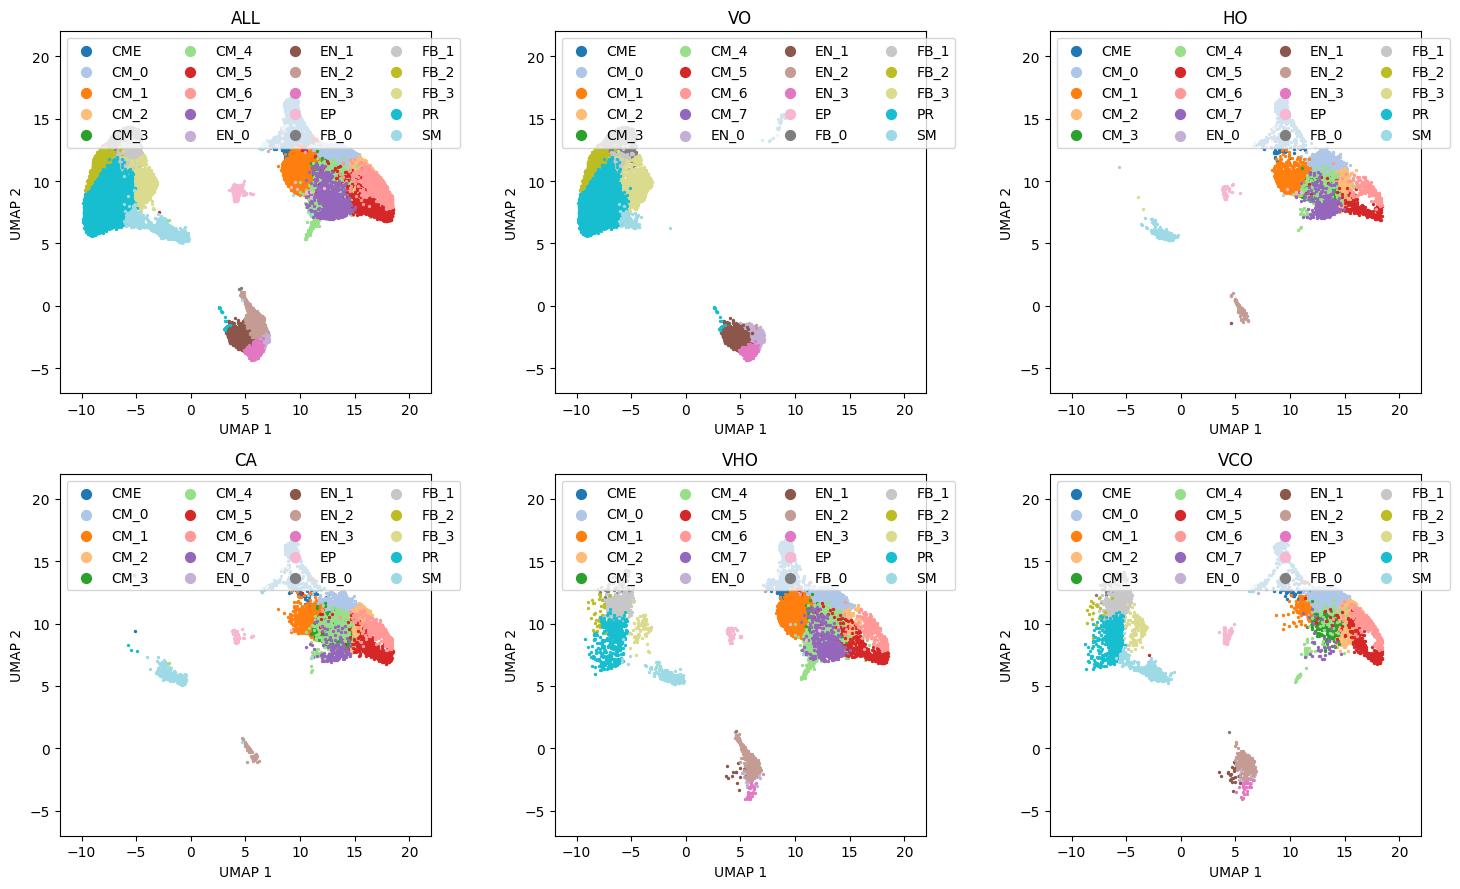

In [27]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cell_type_subcluster):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper left', markerscale=5, ncol=4)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 22])
    axs[i].set_ylim([-7, 22])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/sample_recollect.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

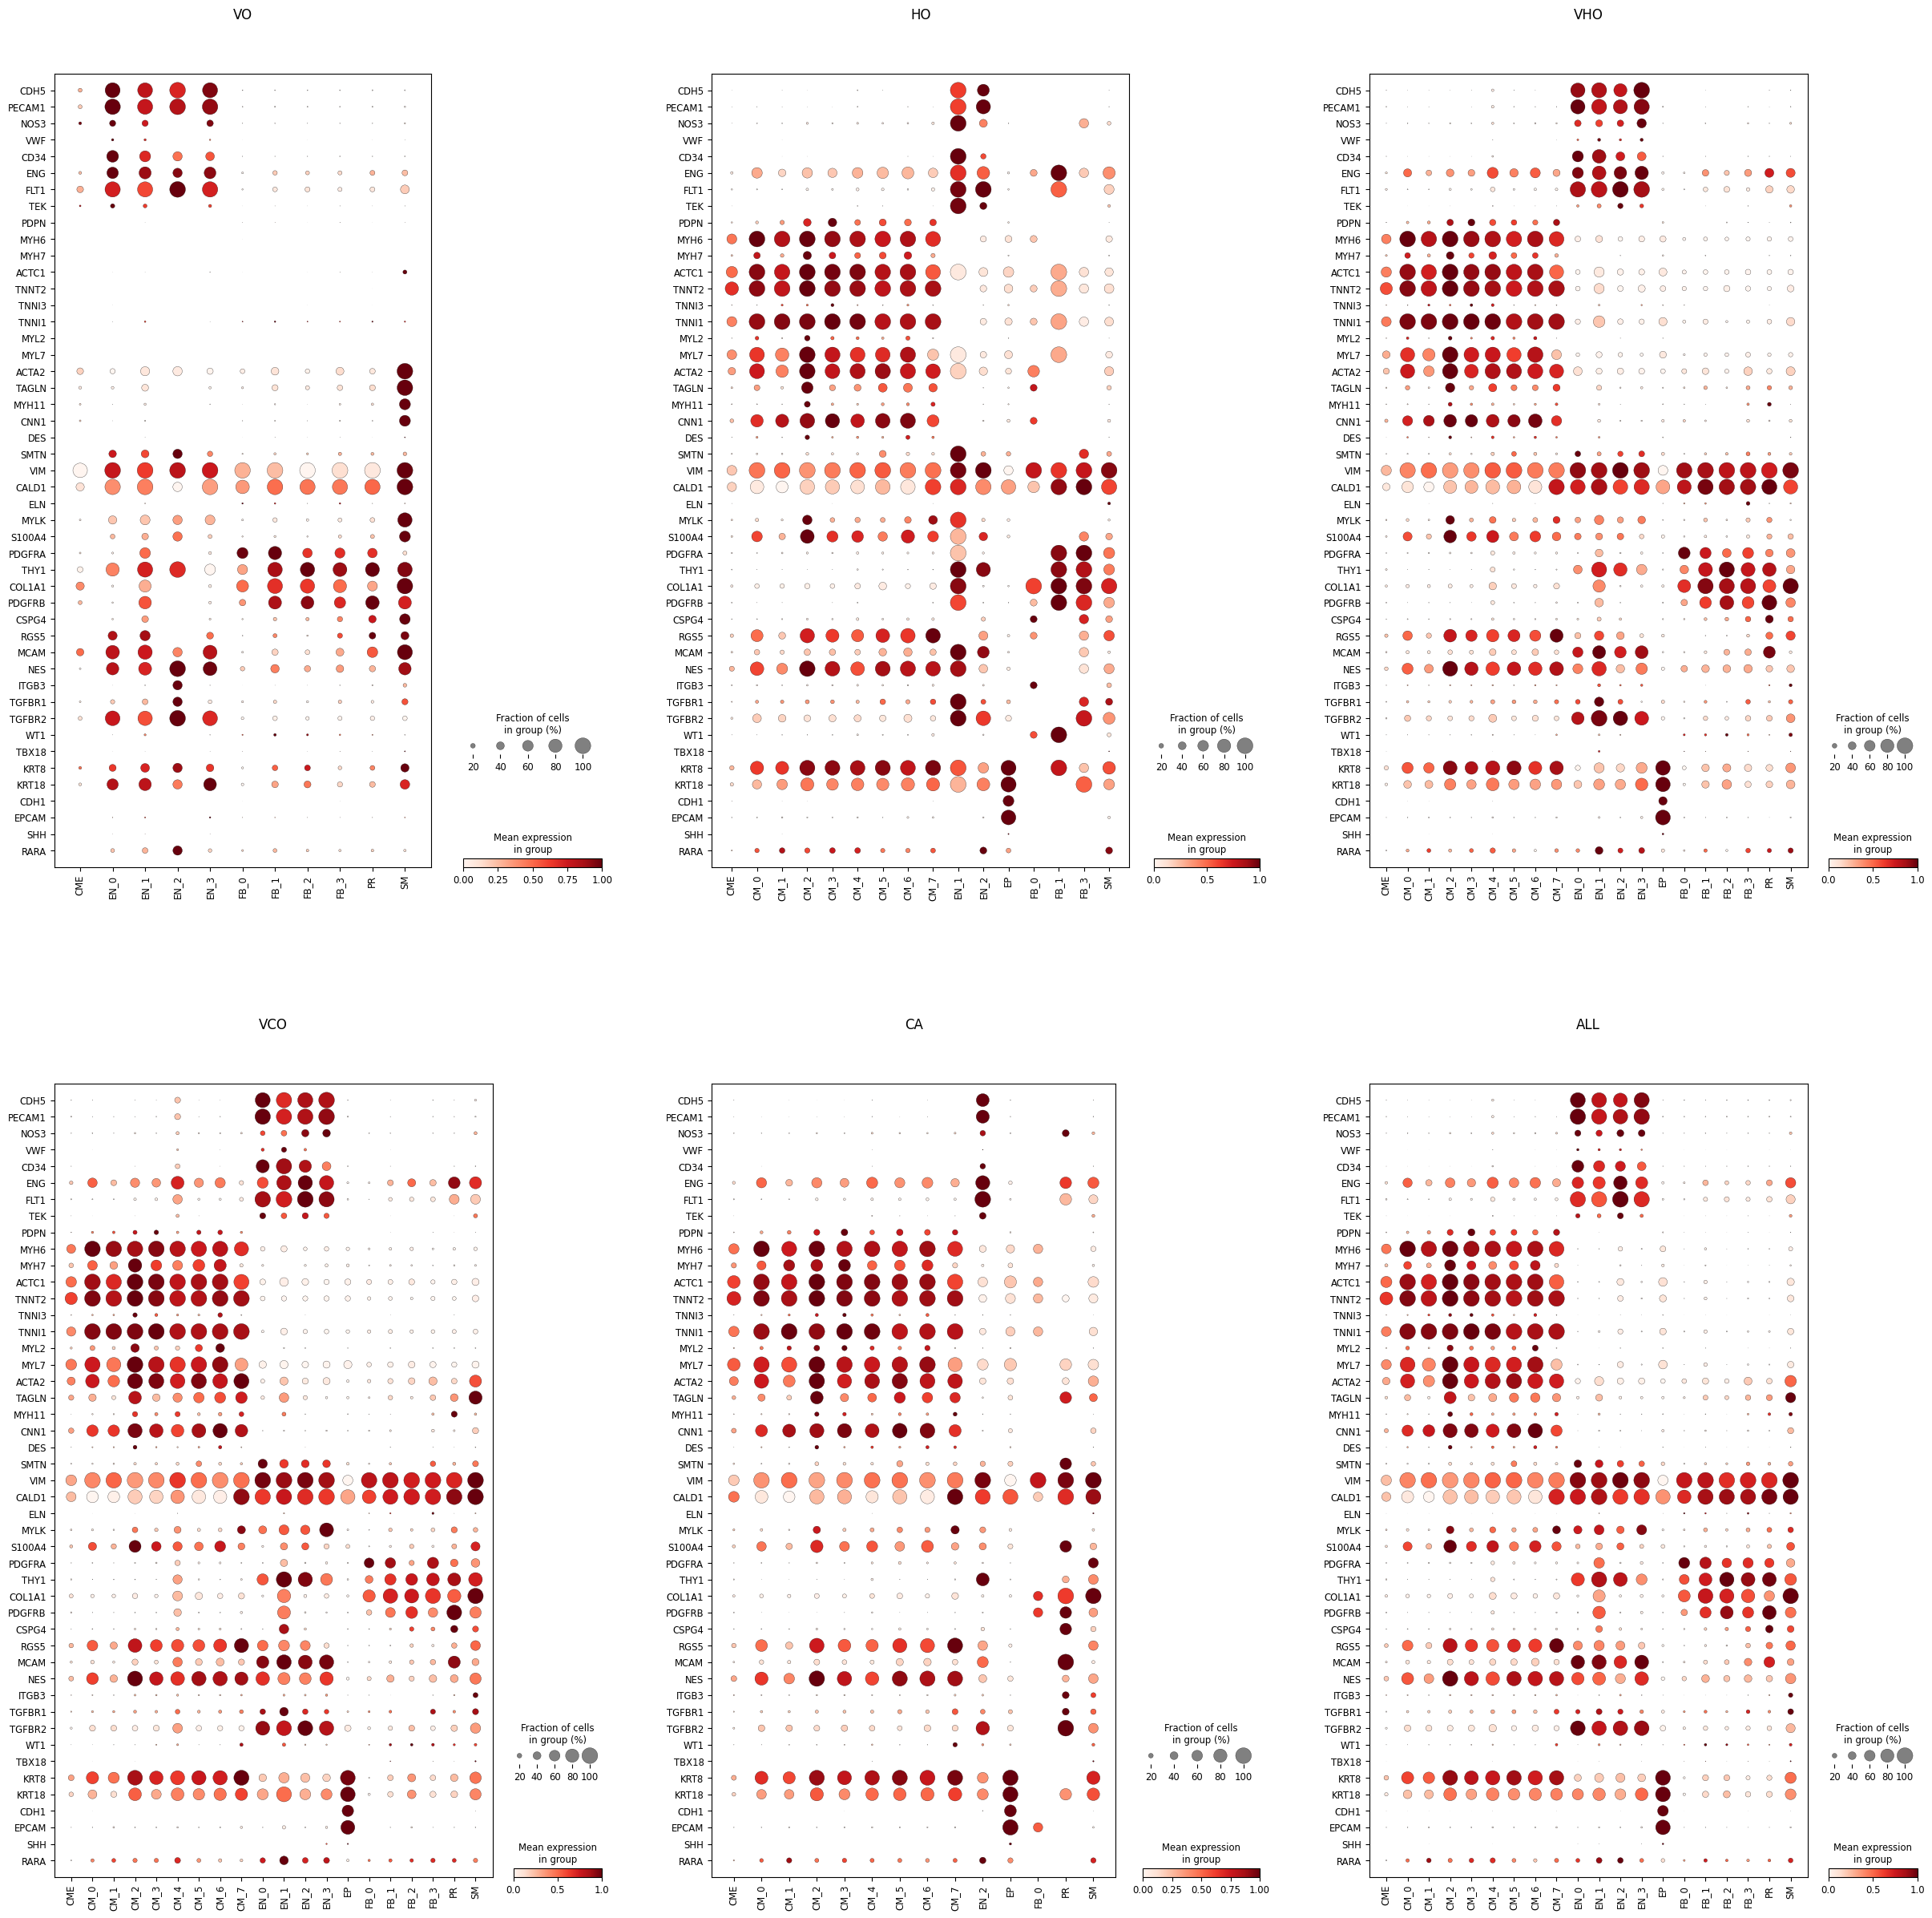

In [26]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/sample_recollect/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_celltype_subcluster.png')
plt.show()

### 2.6 plots

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


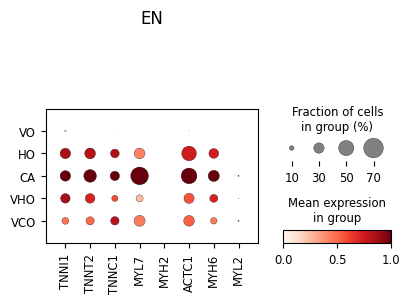

/tmp/ipykernel_1096662/3297408874.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['batch'][0] = "HO"
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


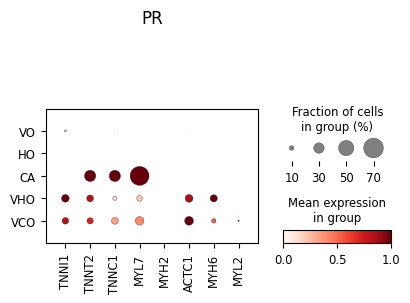

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


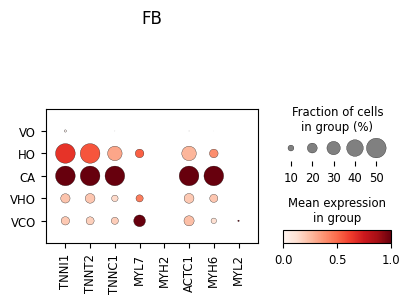

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


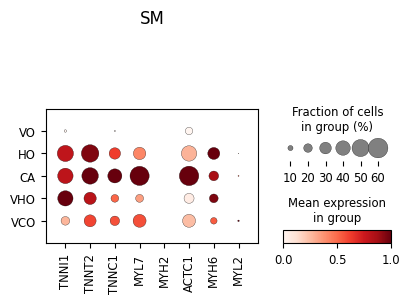

/tmp/ipykernel_1096662/3297408874.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['batch'][0] = "VO"
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


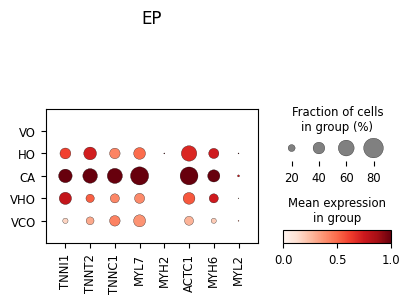

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


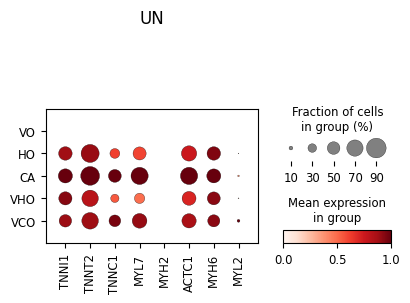

In [50]:
for ct in ["EN", "PR", "FB", "SM", "EP", "CME"]:
    
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
    
    marker_dict = ["TNNI1", "TNNT2", "TNNC1", "MYL7", "MYH2", "ACTC1", "MYH6", "MYL2"]

    if ct == "PR":
        pat = adata[0].copy()
        pat.obs['batch'] = pat.obs['batch'].astype("str")
        pat.obs['batch'][0] = "HO"
        pat.obs['batch'] = pat.obs['batch'].astype("category")
        pat.X.data[:] = 0
        adata = adata.concatenate(pat, batch_key="dump")
        adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)
        # adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'CA', 'VHO', 'VCO'], ordered=True)
    elif ct == "EP":
        pat = adata[0].copy()
        pat.obs['batch'] = pat.obs['batch'].astype("str")
        pat.obs['batch'][0] = "VO"
        pat.obs['batch'] = pat.obs['batch'].astype("category")
        pat.X.data[:] = 0
        adata = adata.concatenate(pat, batch_key="dump")
        adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)
        # adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['HO', 'CA', 'VHO', 'VCO'], ordered=True)
    else:
        adata.obs['batch'] = adata.obs['batch'].cat.reorder_categories(['VO', 'HO', 'CA', 'VHO', 'VCO'], ordered=True)

    if ct == "CME":
        sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title="UN")
    else:
        sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", title=ct)

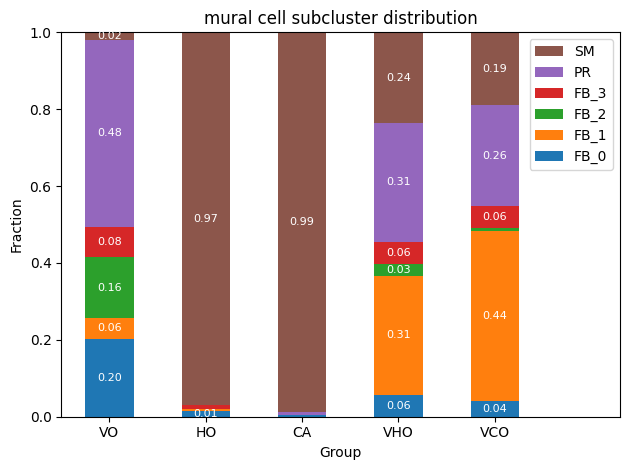

In [45]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        adata_sample = adata_sample[
            np.logical_or(np.logical_or(adata_sample.obs['cell_type'] == "PR", adata_sample.obs['cell_type'] == "FB"), adata_sample.obs['cell_type'] == "SM")
        ]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.3))
plt.xticks(rotation=0)
plt.title("mural cell subcluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()

## 3. DE between samples

In [28]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano

In [29]:
adata_BVO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VO.h5ad')
adata_HO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/CA.h5ad')
adata_BHO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VCO.h5ad')

adatas = {'HO': adata_HO, 'VO': adata_BVO, 'CA': adata_CM3O, 'VHO': adata_BHO, 'VCO': adata_CM3B}

In [30]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [31]:
def volcano_plot2(adata1, celltype_subcluster1, celltype_subcluster2, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1
    pvalue_thres = 5
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

### 3.1 Cardiomyocyte

In [32]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM

In [33]:
celltype = 'CM'
adata_list = ['HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.2 Endothelial cell

In [34]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN

In [35]:
celltype = 'EN'
adata_list = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.3 Fibroblast

In [36]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB

In [37]:
celltype = 'FB'
adata_list = ['VO', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.4 Epithelial

In [38]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EP

In [39]:
celltype = 'EP'
adata_list = ['HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.5 Smooth muscle cell

In [40]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/SM

In [41]:
celltype = 'SM'
adata_list = ['VO', 'HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.6 Pericytes

In [42]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/PR

In [43]:
celltype = 'PR'
adata_list = ['VO', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.7 Cardiomesoderm

In [44]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CME

In [45]:
celltype = 'CME'
adata_list = ['HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

## 4. DE between subclusters

In [46]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN_subcluster

In [47]:
ct = "EN"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if ct in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

In [48]:
ct = "FB"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if ct in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

In [49]:
ct = "CM"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if f"{ct}_" in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1859511/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

## 5. Velocity

In [39]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity

In [50]:
%%bash
qsub /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/scVelo_job.sh

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 111029615 ("scVelo_job.sh") has been submitted


In [ ]:
# activate scVelo env for this

import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
loom_file_names = ['BVO', 'HO', 'CM3O', 'BHO', 'CM3B']
adata_file_names = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, 5):

    loom_file = f'/home/herbert/PyProjects/cocultured_organ/data/240603/SC160__{loom_file_names[i]}-JW-052224/SC160__{loom_file_names[i]}-JW-052224.loom'
    ldata = sc.read(loom_file, cache=True)
    adata = sc.read_h5ad(f'/home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect/{adata_file_names[i]}.h5ad')
    adata = scv.utils.merge(adata, ldata)

    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    scv.tl.velocity(adata)
    scv.tl.velocity_graph(adata)
    scv.pl.velocity_embedding_stream(adata, basis='umap', color='cell_type_subcluster', save=f"{WORK_DIR}/velocity/{adata_file_names[i]}.png")

## 6. GO enrichment

In [9]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/GO_enrich

In [8]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/GO_enrich

In [76]:
import scanpy as sc
import gseapy as gp
import pandas as pd

sample = "VCO"

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

# 1) Differential expression
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')

# 2) Extract results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top_genes_dict = {}
n_top_genes = 100

for group in groups:
    gene_names = result['names'][group][:n_top_genes].tolist()
    pvals_adj = result['pvals_adj'][group][:n_top_genes].tolist()
    df = pd.DataFrame({'gene': gene_names, 'pval_adj': pvals_adj})
    top_genes_dict[group] = df

# 3) GO Enrichment with Enrichr library in GSEApy
library_name = 'GO_Biological_Process_2021'
enrichment_results = {}

for cell_type, df_genes in top_genes_dict.items():
    if cell_type == "CME":
        continue
    
    gene_list = df_genes['gene'].tolist()
    
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[library_name],
        organism='Human',  
        outdir=f"{WORK_DIR}/GO_enrich/{cell_type}"
    )
    
    enrichment_results[cell_type] = enr.results

# 4) Inspect results
for cell_type, df_res in enrichment_results.items():
    print(f"Top terms for {cell_type}")
    print(df_res[['Term','P-value','Adjusted P-value','Genes']].head(10))
    print("-----")

Top terms for CM
                                                Term       P-value  \
0                    muscle contraction (GO:0006936)  2.449810e-26   
1                     heart contraction (GO:0060047)  5.801818e-25   
2            cardiac muscle contraction (GO:0060048)  4.619338e-22   
3         actin-myosin filament sliding (GO:0033275)  2.652338e-21   
4               muscle filament sliding (GO:0030049)  2.652338e-21   
5           striated muscle contraction (GO:0006941)  6.518196e-21   
6   cardiac muscle tissue morphogenesis (GO:0055008)  2.562614e-20   
7       cardiac muscle cell development (GO:0055013)  1.659575e-15   
8  ventricular cardiac muscle tissue morphogenesi...  6.390400e-14   
9   cardiac muscle cell differentiation (GO:0055007)  2.020757e-13   

   Adjusted P-value                                              Genes  
0      2.422862e-23  MYBPC3;TMOD1;MYOM1;SMPX;ACTN2;TNNC1;TPM1;SLC8A...  
1      2.868999e-22  MYBPC3;RYR2;TNNC1;TPM1;ATP1B1;SLC8A1;TTN;TRDN